# Training the U-Net Model for Gap Filling (Streaming Architecture)

This notebook trains a Convolutional Neural Network (CNN) to reconstruct missing Chlorophyll-a (Chl-a) data caused by cloud cover. 

Unlike standard in-memory training, this notebook utilizes a high-performance **streaming architecture** via `xbatcher`. It reads raw, chunked `IO.zarr` data directly from a local network drive, dynamically engineers features (like fake clouds and time variables) on the fly, and feeds them directly to the GPU. This prevents memory (RAM) crashes when working with massive oceanographic datasets.

**Environment Setup:** * Runs in JupyterHub with GPU (`pangeo/ml-notebook:2025.08.14` or newer).
* Ensure `mindthegap` and `zarr` are installed in your environment.

In [4]:
!pip install git+https://github.com/SAFS-Varanasi-Internship/mindthegap.git

  Cloning https://github.com/SAFS-Varanasi-Internship/mindthegap.git to /tmp/pip-req-build-1oh13u57
  Running command git clone --filter=blob:none --quiet https://github.com/SAFS-Varanasi-Internship/mindthegap.git /tmp/pip-req-build-1oh13u57
  Resolved https://github.com/SAFS-Varanasi-Internship/mindthegap.git to commit 41c36ca8e9ba0c1aed78839f834ddccebfab94f5
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [5]:
import os
import calendar
import sys
sys.path.insert(0, os.path.abspath('.'))

# 1. Set TF Environment Variables (MUST be before importing TF)
os.environ.pop("TF_CUDNN_DETERMINISTIC", None)
os.environ.pop("TF_CUDNN_USE_AUTOTUNE", None)
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_CPP_VMODULE"] = "conv_algorithm_picker=0,cuda_timer=0"

# 2. Import TF and Configure GPUs immediately
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            # Redundant with the env var, but good practice to explicitly enforce
            tf.config.experimental.set_memory_growth(gpu, True)
            details = tf.config.experimental.get_device_details(gpu)
            print(f"Memory growth successfully enabled. GPU Details: {details}")
    except RuntimeError as e:
        # Catching the error if GPUs are already initialized
        print(f"RuntimeError during GPU setup: {e}")
else:
    print("No GPU available")

# 3. Third-party Data Science & Plotting Imports
import numpy as np
import pandas as pd
import xarray as xr
import dask.array as da
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 4. Keras and Specific/Custom Imports
from tensorflow.keras import Input, layers
from tensorflow.keras.callbacks import EarlyStopping
from xbatcher import BatchGenerator
import mindthegap as mtg

Memory growth successfully enabled. GPU Details: {'compute_capability': (7, 5), 'device_name': 'Tesla T4'}


## 1. Data Loading & Global Statistics
Load the raw Zarr file from the local shared drive and establish the normalization statistics.

In [6]:
# 1. Load the RAW data from the local shared drive
zarr_raw = xr.open_zarr(os.path.expanduser("~/shared/mind_the_chl_gap/IO.zarr"))

# 2. Crop to your specific Arab Sea bounding box
lat_min, lat_max = 5, 31
lon_min, lon_max = 42, 80
zarr_raw = zarr_raw.sel(lat=slice(lat_max, lat_min), lon=slice(lon_min, lon_max))

# 3. Apply the multiple of 8 crop for the U-Net architecture
ds_cropped = mtg.crop_to_multiple(zarr_raw, multiple=8)

# 4. Cast floats to float32 to save memory
for v in ds_cropped.data_vars:
    if np.issubdtype(ds_cropped[v].dtype, np.floating):
        ds_cropped[v] = ds_cropped[v].astype("float32")

# 5. Load Target Statistics from local prep file
datadir = "/home/jovyan/shared-public/mindthegap/data"
zarr_label = "2015_3_ArabSea"
mean_std = np.load(f'{datadir}/{zarr_label}.npy', allow_pickle=True).item()
y_mean, y_std = mean_std['CHL'][0], mean_std['CHL'][1]

# 6. Define Global Feature Statistics for on-the-fly normalization
feature_stats = {
    'sst': [28.0, 2.0],  
    'so':  [36.0, 1.0],  
    'ug_curr': [0.0, 0.5],
    'v_curr': [0.0, 0.5]
}

print("Raw data loaded and global statistics initialized.")

Raw data loaded and global statistics initialized.


In [7]:
# LOCAL/TEMPORARY: on-the-fly equivalent of mtg.data_preprocessing.
# Mirrors mindthegap/create_zarr.py exactly, but returns a LAZY standardized
# xr.Dataset instead of writing a zarr — so xbatcher streams it from raw IO.zarr.
def build_standardized_lazy(zarr_ds, features, train_year, train_range):
    numer_features = []
    cat_features = []

    for feature in features:
        numer_features.append(zarr_ds[feature].data)

    CHL_data = np.log(zarr_ds['CHL_cmes-level3'].copy())  # label: log(level3), NOT gapfree

    time_data = da.array(zarr_ds.time)
    day_rad = (time_data - np.datetime64("1900-01-01")) / np.timedelta64(1, "D") / 365 * 2 * np.pi
    day_rad = day_rad.astype(np.float32)
    day_sin = np.sin(day_rad)
    day_cos = np.cos(day_rad)
    day_sin = np.tile(day_sin[:, np.newaxis, np.newaxis], (1,) + CHL_data[0].shape)
    day_sin = da.rechunk(day_sin, (100, *day_sin.shape[1:]))
    numer_features.append(day_sin)
    day_cos = np.tile(day_cos[:, np.newaxis, np.newaxis], (1,) + CHL_data[0].shape)
    day_cos = da.rechunk(day_cos, (100, *day_cos.shape[1:]))
    numer_features.append(day_cos)

    day_shift_flag = np.vstack((zarr_ds['CHL_cmes-cloud'].data[10:], zarr_ds['CHL_cmes-cloud'].data[:10]))
    assert CHL_data.shape == day_shift_flag.shape
    masked_CHL = da.where(day_shift_flag == 0, np.nan, CHL_data)
    numer_features.append(masked_CHL)

    prev_day = np.vstack((np.zeros((1,) + CHL_data[0].shape), CHL_data.data[:-1]))
    numer_features.append(prev_day)
    next_day = np.vstack((CHL_data.data[1:], np.zeros((1,) + CHL_data[0].shape)))
    numer_features.append(next_day)

    land_flag = da.zeros(CHL_data.shape)
    land_flag = da.where(zarr_ds['CHL_cmes-cloud'][0] == 2, 1, land_flag)
    cat_features.append(land_flag)
    real_cloud_flag = da.zeros(CHL_data.shape)
    real_cloud_flag = da.where(zarr_ds['CHL_cmes-cloud'] == 1, 1, real_cloud_flag)
    cat_features.append(real_cloud_flag)
    valid_CHL_flag = da.zeros(CHL_data.shape)
    valid_CHL_flag = da.where(~da.isnan(masked_CHL), 1, valid_CHL_flag)
    cat_features.append(valid_CHL_flag)
    fake_cloud_flag = da.zeros(CHL_data.shape)
    fake_cloud_flag = da.where((land_flag + real_cloud_flag + valid_CHL_flag) == 0, 1, fake_cloud_flag)
    cat_features.append(fake_cloud_flag)

    train_start_ind = np.where(zarr_ds.time.values == np.datetime64(f'{train_year}-01-01'))[0][0]
    train_end_ind = np.where(zarr_ds.time.values == np.datetime64(f'{train_year + train_range}-01-01'))[0][0]

    feat_mean, feat_stdev = [], []
    for feature in numer_features:
        feature_train = feature[train_start_ind:train_end_ind]
        feat_mean.append(da.nanmean(feature_train).compute())
        feat_stdev.append(da.nanstd(feature_train).compute())

    feature_shape = numer_features[0].shape
    numer_features_stdized = []
    for feature, mean, stdev in zip(numer_features, feat_mean, feat_stdev):
        numer_features_stdized.append((feature - da.full(feature_shape, mean)) / da.full(feature_shape, stdev))

    CHL_mean = da.nanmean(CHL_data).compute()
    CHL_stdev = da.nanstd(CHL_data).compute()
    CHL_data_stdized = (CHL_data - da.full(feature_shape, CHL_mean)) / da.full(feature_shape, CHL_stdev)

    numer_var_names = list(features) + ['sin_time', 'cos_time', 'masked_CHL', 'prev_day_CHL', 'next_day-CHL']
    cat_var_names = ['land_flag', 'real_cloud_flag', 'valid_CHL_flag', 'fake_cloud_flag']

    data_vars = {}
    for name, arr in zip(numer_var_names, numer_features_stdized):
        data_vars[name] = (("time", "lat", "lon"), arr)
    for name, arr in zip(cat_var_names, cat_features):
        data_vars[name] = (("time", "lat", "lon"), arr)
    data_vars["CHL"] = (("time", "lat", "lon"), CHL_data_stdized.data)

    coords = {c: zarr_ds.coords[c] for c in ("time", "lat", "lon")}
    ds_out = xr.Dataset(data_vars=data_vars, coords=coords).chunk({"time": 100, "lat": -1, "lon": -1})
    stats = {'CHL': np.array([CHL_mean, CHL_stdev]),
             'masked_CHL': np.array([feat_mean[-3], feat_stdev[-3]])}
    return ds_out, stats

features = ['u_wind', 'v_wind', 'sst', 'air_temp']
train_year, train_range, val_range, test_range = 2015, 3, 1, 1
ds_std, stats = build_standardized_lazy(ds_cropped, features, train_year, train_range)
y_mean, y_std = stats['CHL'][0], stats['CHL'][1]
print("Lazy standardized dataset built. Channels:", [v for v in ds_std.data_vars if v != 'CHL'])

Lazy standardized dataset built. Channels: ['u_wind', 'v_wind', 'sst', 'air_temp', 'sin_time', 'cos_time', 'masked_CHL', 'prev_day_CHL', 'next_day-CHL', 'land_flag', 'real_cloud_flag', 'valid_CHL_flag', 'fake_cloud_flag']


## 2. Build model: U-Net

#### What is U-Net?
U-Net is a Convolutional Neural Network (CNN) architecture. CNNs are deep learning models particularly effective for visual data and high-dimensional spatial analysis. They are powerful in capturing spatial hierarchies and patterns. 

U-Net follows an autoencoder architecture. The **encoder** half down-samples input images progressively and extracts features, while the **decoder** half constructs predictions based on these features. It is highly effective and accurate even with relatively limited data.

#### Model Architecture
This model uses three encoder layers (filter sizes 64, 128, 256) and three decoder layers (filter sizes 128, 64, 1). 
* Each encoder block consists of two `Conv2D` layers, one `MaxPool2D` layer, and one `BatchNormalization` layer. 
* Each decoder block consists of one `Conv2DTranspose` layer, one `Concatenate` layer, two `Conv2D` layers, and one `BatchNormalization` layer. 
* The output of the final decoder layer is the gap-filled prediction of Chl-a.

**Layer Definitions:**
* `Conv2D`: Applies 2D convolution operations to the input for feature detection (lines, edges, patterns) in the encoder, and for making predictions in the decoder. 
  * `filters`: Number of output channels and features detected. 
  * `kernel_size`: Size of the filters (all filters here are 3x3). 
  * `padding`: Adds extra pixels to inputs. `same` ensures output dimensions match the input. 
  * `activation`: Introduces non-linearity. Most layers use `ReLU` (outputs input directly if positive, 0 if negative). The final layer uses `linear` due to potential negative values in log(Chl-a) predictions.
* `MaxPooling2D`: Downsamples the input by taking the maximum in a given window (2x2). It reduces computational complexity while retaining significant features.
* `BatchNormalization`: Normalizes the input, reducing overfitting and improving generalizability.
* `Conv2DTranspose`: Performs a "reverse" convolution to upsample the input, doubling the spatial dimensions.
* `Concatenate`: Merges the upsampled feature maps with the high-resolution feature maps passed over from the corresponding encoder stage.

#### Model Compilation
We use `.compile()` to configure the model for training.
* `optimizer`: Adjusts model parameters during training to minimize loss. We use `Adam` for faster convergence via adaptive learning rates.
* `loss`: The objective function the model minimizes. We use Mean Squared Error (MSE) for its effectiveness in regression tasks.
* `metrics`: Evaluators monitored during training. We track Mean Absolute Error (MAE) for additional performance context.

In [8]:
def UNet(input_shape):
    inputs = Input(shape=input_shape)
    x = inputs
    filters = [64, 128, 256]
    ec_images = []

    for filter in filters:
        ec_images.append(x)
        x = layers.Conv2D(filters=filter, kernel_size=(3, 3), padding='same', activation='relu')(x)
        x = layers.Conv2D(filters=filter, kernel_size=(3, 3), padding='same', activation='relu')(x)
        x = layers.MaxPooling2D()(x)
        x = layers.BatchNormalization()(x)

    for filter, ec_image in zip(filters[:-1][::-1], ec_images[::-1][:-1]):
        x = layers.Conv2DTranspose(filter, 3, 2, padding='same')(x)
        x = layers.concatenate([x, ec_image])
        x = layers.Conv2D(filters=filter, kernel_size=(3, 3), padding='same', activation='relu')(x)
        x = layers.Conv2D(filters=filter, kernel_size=(3, 3), padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)

    x = layers.Conv2DTranspose(filter, 3, 2, padding='same')(x)
    x = layers.concatenate([x, ec_images[0]])
    x = layers.Conv2D(filters=filter, kernel_size=(3, 3), padding='same', activation='relu')(x)
    
    outputs = layers.Conv2D(filters=1, kernel_size=(3,3), padding='same', activation='linear')(x)

    unet_model = tf.keras.Model(inputs, outputs, name='U-net')
    unet_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return unet_model

## 3. Streaming Pipeline & Dynamic Feature Engineering

Because we cannot fit the entire dataset in memory, we use `xbatcher` to stream 100-day blocks of data. We then use a Python Generator (`make_tf_gen`) to engineer the features our model needs milliseconds before passing them to the GPU.

**Dynamic Features Engineered:**
* **Fake Clouds:** To teach the model how to fill gaps, we simulate missing data by taking the real cloud mask from 10 days in the future and applying it to today's gap-free truth.
* **Masked CHL:** The input Chlorophyll-a data with holes punched into it where the fake clouds sit.
* **Time Variables:** Sine and Cosine waves representing the day of the year, helping the model learn seasonal oceanographic patterns.

The generator standardizes these features, stacks them into a 6-channel tensor, and yields them to the TensorFlow dataset iteratively.

In [9]:
X_vars = [v for v in ds_std.data_vars if v != 'CHL']
num_features = len(X_vars)
lat_size = ds_std.sizes['lat']
lon_size = ds_std.sizes['lon']
input_shape = (lat_size, lon_size, num_features)

model = UNet(input_shape)
model.summary()

output_signature = (
    tf.TensorSpec(shape=(lat_size, lon_size, num_features), dtype=tf.float32),
    tf.TensorSpec(shape=(lat_size, lon_size, 1), dtype=tf.float32)
)

ds_train = ds_std.sel(time=slice(f'{train_year}-01-01', f'{train_year+train_range}-01-01'))
ds_val = ds_std.sel(time=slice(f'{train_year+train_range}-01-01', f'{train_year+train_range+val_range}-01-01'))

input_dims = {"time": 100, "lat": lat_size, "lon": lon_size}
input_overlap = {"time": 0, "lat": 0, "lon": 0}
train_batcher = BatchGenerator(ds_train, input_dims=input_dims, input_overlap=input_overlap)
val_batcher = BatchGenerator(ds_val, input_dims=input_dims, input_overlap=input_overlap)

# Pass-through: data is already logged/masked/standardized, so just stack channels and yield.
def make_tf_gen(batcher, x_vars):
    def gen():
        for batch in batcher:
            batch = batch.load()
            time_len = batch.sizes["time"]
            for t in range(time_len):
                x = np.stack(
                    [np.nan_to_num(batch[v].isel(time=t).values, nan=0.0) for v in x_vars],
                    axis=-1
                ).astype(np.float32)
                y = np.nan_to_num(batch['CHL'].isel(time=t).values, nan=0.0).astype(np.float32)[..., np.newaxis]
                yield x, y
    return gen

train_dataset = tf.data.Dataset.from_generator(
    make_tf_gen(train_batcher, X_vars), output_signature=output_signature
).shuffle(512).batch(1).repeat().prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_generator(
    make_tf_gen(val_batcher, X_vars), output_signature=output_signature
).batch(1).repeat().prefetch(tf.data.AUTOTUNE)

train_steps = (ds_train.sizes['time'] // 100) * 100
val_steps = (ds_val.sizes['time'] // 100) * 100
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_dataset,
    epochs=50,
    steps_per_epoch=train_steps,
    validation_data=val_dataset,
    validation_steps=val_steps,
    callbacks=[early_stop]
)


Model: "U-net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 104, 152,  │          0 │ -                 │
│ (InputLayer)        │ 13)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 104, 152,  │      7,552 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 104, 152,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 52, 76,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 52, 76,    │        256 │ max_pooling2d[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 52, 76,    │     73,856 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 52, 76,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 26, 38,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 26, 38,    │        512 │ max_pooling2d_1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 26, 38,    │    295,168 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 26, 38,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 13, 19,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 13, 19,    │      1,024 │ max_pooling2d_2[… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 26, 38,    │    295,040 │ batch_normalizat… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 26, 38,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 26, 38,    │    295,040 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 26, 38,    │    147,584 │ conv2d_6[0][0]  

 Total params: 2,157,825 (8.23 MB)

 Trainable params: 2,156,545 (8.23 MB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/50


2026-06-30 18:47:07.015483: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-30 18:47:07.321291: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-30 18:47:07.665718: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-30 18:47:07.817724: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-30 18:47:08.810690: E external/local_xla/xla/stream_

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 116s 69ms/step - loss: 0.0264 - mae: 0.0777 - val_loss: 0.0176 - val_mae: 0.0571
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 79s 65ms/step - loss: 0.0131 - mae: 0.0442 - val_loss: 0.0232 - val_mae: 0.0534
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 86s 68ms/step - loss: 0.0122 - mae: 0.0387 - val_loss: 0.0131 - val_mae: 0.0386
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 82s 67ms/step - loss: 0.0112 - mae: 0.0360 - val_loss: 0.0129 - val_mae: 0.0383
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 80s 65ms/step - loss: 0.0104 - mae: 0.0331 - val_loss: 0.0148 - val_mae: 0.0435
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 86s 70ms/step - loss: 0.0096 - mae: 0.0307 - val_loss: 0.0123 - val_mae: 0.0349
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 80s 70ms/step - loss: 0.0095 - mae: 0.0310 - val_loss: 0.0129 - val_mae: 0.0335
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 80s 69ms/step - loss: 0.0092 - mae: 0.0292 - val_loss: 0.0107 - val_mae: 0.0325
Epoch 9/50
1000/1000 ━━━━━━━━━━━━━

## 4. Model Evaluation & Saving

Testing is also performed via the streaming generator to prevent memory overflow. We use `.evaluate()` on a dedicated holdout test dataset (e.g., data from a subsequent year unseen by the model during training). 

Because the generator runs continuously, we explicitly pass `test_steps` to the evaluation function so Keras knows exactly when to stop requesting new batches.

In [10]:
def evaluate_test_set():
    ds_test = ds_std.sel(time=slice(f'{train_year+train_range+val_range}-01-01',
                                    f'{train_year+train_range+val_range+test_range}-01-01'))
    test_batcher = BatchGenerator(ds_test, input_dims=input_dims, input_overlap=input_overlap)
    test_dataset = tf.data.Dataset.from_generator(
        make_tf_gen(test_batcher, X_vars), output_signature=output_signature
    ).batch(1)
    test_steps = (ds_test.sizes['time'] // 100) * 100
    test_mse, test_mae = model.evaluate(test_dataset, steps=test_steps)
    print(f"Test MSE: {test_mse}")
    print(f"Test MAE: {test_mae}")
    return test_mse, test_mae

test_mse, test_mae = evaluate_test_set()

model_name = 'UNet_Streaming_mse'
folder_path = f'models/{zarr_label}'
os.makedirs(folder_path, exist_ok=True)
model.save(f'{folder_path}/{model_name}.keras')


300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - loss: 0.0104 - mae: 0.0314
Test MSE: 0.01039885450154543
Test MAE: 0.03139892593026161


## 5. Visualizations

Visualizing the model's predictions helps us qualitatively and quantitatively assess its performance. 

* **Prediction vs. Observation:** Compares the U-Net prediction against real Level-3 observations containing natural gaps.
* **Gapfill Comparison:** Compares the U-Net prediction against the highly processed Copernicus Gapfree (Level-4) product. 
* **Annual Mean Absolute Difference (MAD):** Evaluates the average daily error between the model and the gap-free truth over an entire year, plotted alongside the daily cloud percentage to visualize performance under varying levels of missing data.

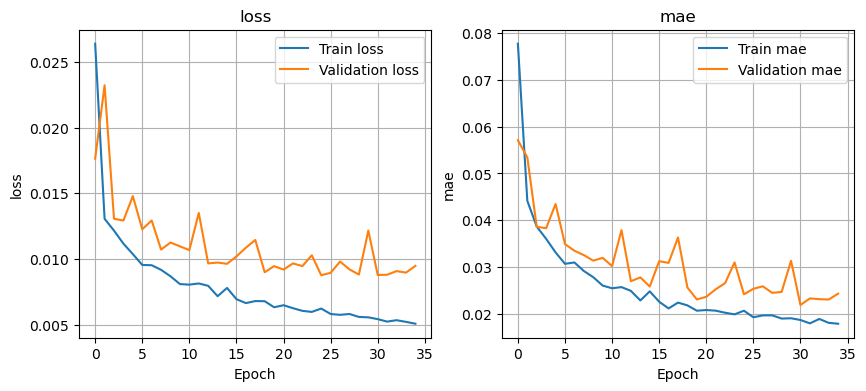

In [11]:
def plot_losses(history):
    history_keys = list(history.history.keys())
    plot_num = len(history_keys) // 2
    plt.figure(figsize=(5 * plot_num, 4))
    for i in range(plot_num):
        train_key = history_keys[i]
        val_key = history_keys[i + plot_num]
        plt.subplot(1, plot_num, i + 1)
        plt.plot(history.history[train_key], label=f'Train {train_key}')
        plt.plot(history.history[val_key], label=f'Validation {val_key[4:]}')
        plt.title(train_key)
        plt.xlabel('Epoch')
        plt.ylabel(train_key)
        plt.legend(loc='upper right')
        plt.grid(True)
    plt.show()

plot_losses(history)

/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


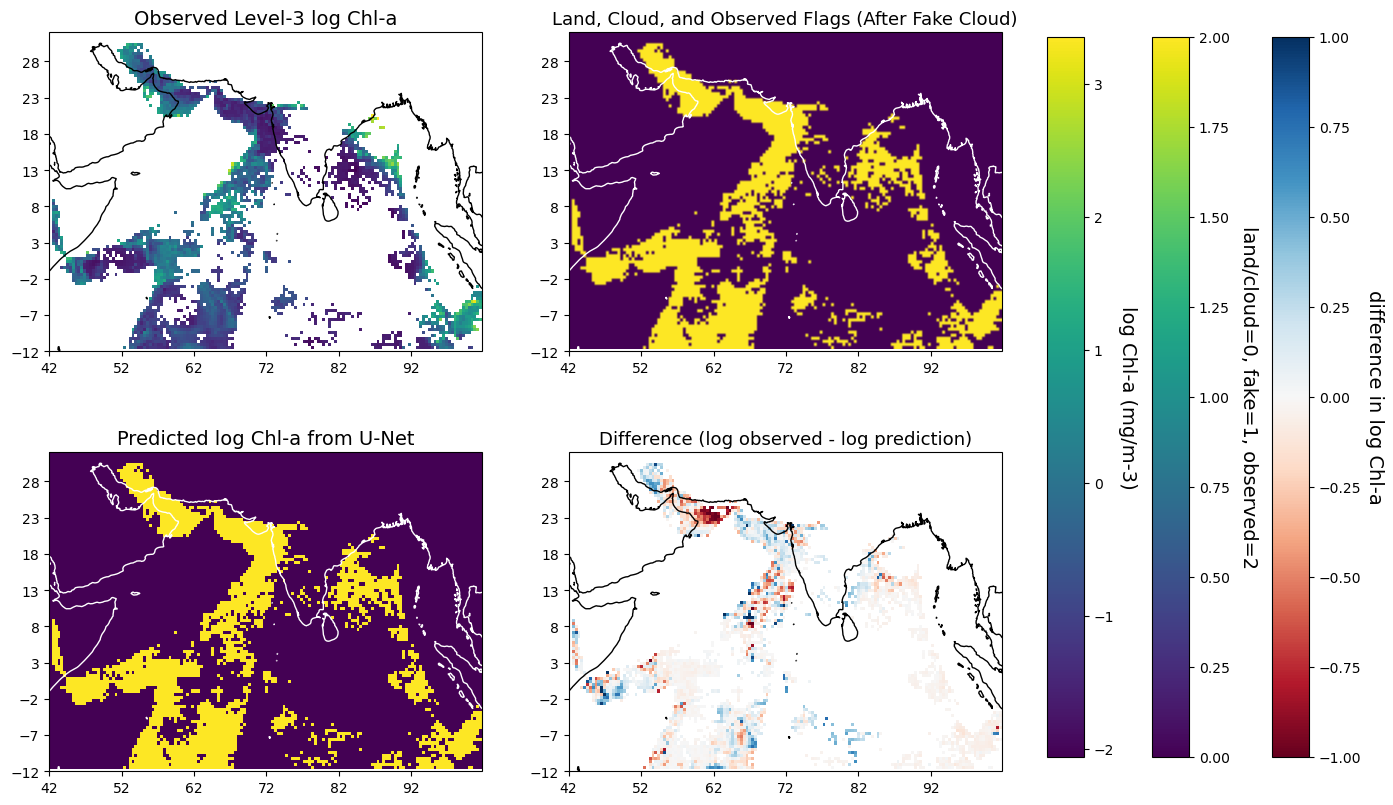

In [13]:
def plot_prediction_observed(zarr_raw, model, date_to_predict):
    target_date = pd.to_datetime(date_to_predict)

    # Input: pull all 13 standardized channels straight from ds_std (already engineered),
    # so this matches training exactly. No on-the-fly feature building / feature_stats here.
    X = np.stack(
        [np.nan_to_num(ds_std[v].sel(time=target_date).values, nan=0.0) for v in X_vars],
        axis=-1
    ).astype(np.float32)

    # Predict and unstandardize with the CHL train stats (y_mean/y_std from build_standardized_lazy)
    predicted_CHL_std = model.predict(X[np.newaxis, ...], verbose=0)[0, :, :, 0]
    predicted_CHL = (predicted_CHL_std * y_std) + y_mean

    # Truth + flags come from the RAW dataset
    zarr_date = zarr_raw.sel(time=target_date)
    fake_cloud_flag = ds_std['fake_cloud_flag'].sel(time=target_date).values

    with np.errstate(divide='ignore', invalid='ignore'):
        true_CHL = np.log(zarr_date['CHL_cmes-level3'].values)
    predicted_CHL = np.where(np.isnan(true_CHL), np.nan, predicted_CHL)
    diff = true_CHL - predicted_CHL

    flag = np.zeros(true_CHL.shape)
    if 'CHL_cmes-land' in zarr_raw:
        flag = np.where(zarr_raw['CHL_cmes-land'].values == 1, 0, flag)
    flag = np.where(zarr_date['CHL_cmes-cloud'].values == 1, 0, flag)
    flag = np.where(fake_cloud_flag == 1, 1, flag)
    flag = np.where(~np.isnan(true_CHL), 2, flag)

    vmax, vmin = np.nanmax((true_CHL, predicted_CHL)), np.nanmin((true_CHL, predicted_CHL))
    extent = [42, 101.75, -11.75, 32]

    # Plotting
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), subplot_kw={'projection': ccrs.PlateCarree()})
    
    im0 = axes[0, 0].imshow(true_CHL, vmin=vmin, vmax=vmax, extent=extent, origin='upper', transform=ccrs.PlateCarree(), interpolation='nearest')
    axes[0, 0].add_feature(cfeature.COASTLINE)
    axes[0, 0].set_xticks(np.arange(42, 102, 10), crs=ccrs.PlateCarree())
    axes[0, 0].set_yticks(np.arange(-12, 32, 5), crs=ccrs.PlateCarree())
    axes[0, 0].set_title('Observed Level-3 log Chl-a', size=14)

    im1 = axes[0, 1].imshow(flag, extent=extent, origin='upper', transform=ccrs.PlateCarree())
    axes[0, 1].add_feature(cfeature.COASTLINE, color='white')
    axes[0, 1].set_xticks(np.arange(42, 102, 10), crs=ccrs.PlateCarree())
    axes[0, 1].set_yticks(np.arange(-12, 32, 5), crs=ccrs.PlateCarree())
    axes[0, 1].set_title('Land, Cloud, and Observed Flags (After Fake Cloud)', size=13)

    im2 = axes[1, 0].imshow(predicted_CHL, vmin=vmin, vmax=vmax, extent=extent, origin='upper', transform=ccrs.PlateCarree(), interpolation='nearest')
    axes[1, 0].add_feature(cfeature.COASTLINE, color='white')
    axes[1, 0].imshow(np.where(flag == 1, np.nan, flag), vmax=2, vmin=0, extent=extent, origin='upper', interpolation='nearest', alpha=1)
    axes[1, 0].set_xticks(np.arange(42, 102, 10), crs=ccrs.PlateCarree())
    axes[1, 0].set_yticks(np.arange(-12, 32, 5), crs=ccrs.PlateCarree())
    axes[1, 0].set_title('Predicted log Chl-a from U-Net', size=14)

    im3 = axes[1, 1].imshow(diff, vmin=-1, vmax=1, extent=extent, origin='upper', transform=ccrs.PlateCarree(), cmap=plt.cm.RdBu, interpolation='nearest')
    axes[1, 1].add_feature(cfeature.COASTLINE)
    axes[1, 1].set_xticks(np.arange(42, 102, 10), crs=ccrs.PlateCarree())
    axes[1, 1].set_yticks(np.arange(-12, 32, 5), crs=ccrs.PlateCarree())
    axes[1, 1].set_title('Difference (log observed - log prediction)', size=13)

    fig.subplots_adjust(right=0.76)
    cbar1 = fig.colorbar(im0, cax=fig.add_axes([0.79, 0.14, 0.025, 0.72]))
    cbar1.ax.set_ylabel('log Chl-a (mg/m-3)', rotation=270, size=14, labelpad=16)
    cbar2 = fig.colorbar(im1, cax=fig.add_axes([0.86, 0.14, 0.025, 0.72]))
    cbar2.ax.set_ylabel('land/cloud=0, fake=1, observed=2', rotation=270, size=14, labelpad=20)
    cbar3 = fig.colorbar(im3, cax=fig.add_axes([0.94, 0.14, 0.025, 0.72]))
    cbar3.ax.set_ylabel('difference in log Chl-a', rotation=270, size=14, labelpad=16)
    
    plt.show()

# Run Prediction Map
plot_prediction_observed(ds_cropped, model, '2020-09-08')


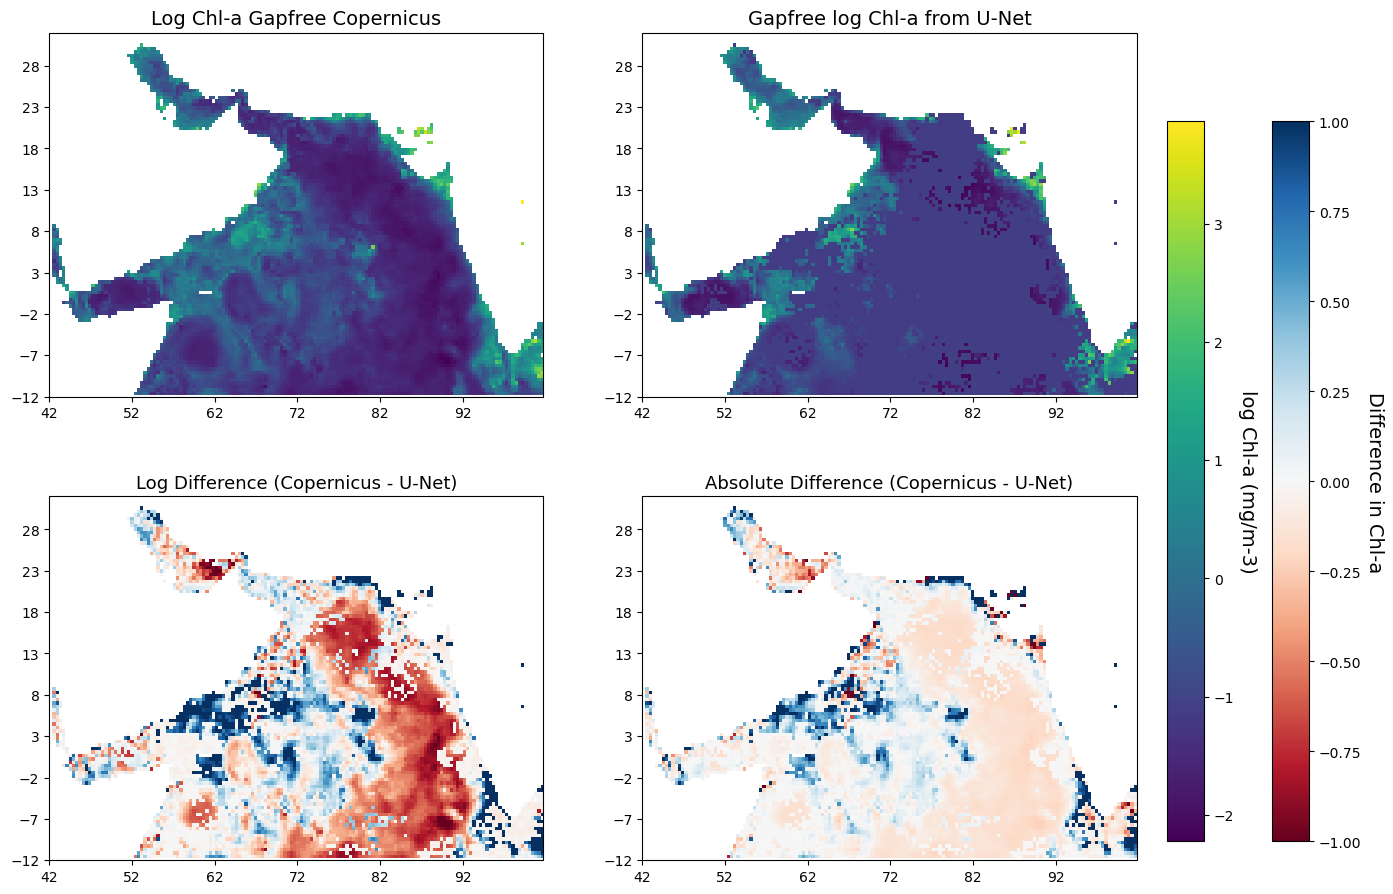

In [15]:
def plot_prediction_gapfill(zarr_raw, model, date_to_predict):
    target_date = pd.to_datetime(date_to_predict)
    zarr_date = zarr_raw.sel(time=target_date)

    # Input: all 13 standardized channels straight from ds_std (matches training)
    X = np.stack(
        [np.nan_to_num(ds_std[v].sel(time=target_date).values, nan=0.0) for v in X_vars],
        axis=-1
    ).astype(np.float32)

    predicted_CHL_std = model.predict(X[np.newaxis, ...], verbose=0)[0, :, :, 0]
    predicted_CHL = (predicted_CHL_std * y_std) + y_mean

    with np.errstate(divide='ignore', invalid='ignore'):
        true_CHL = np.log(zarr_date['CHL_cmes-gapfree'].values)

    predicted_CHL = np.where(np.isnan(true_CHL), np.nan, predicted_CHL)
    log_diff = true_CHL - predicted_CHL
    diff = np.exp(true_CHL) - np.exp(predicted_CHL)

    vmax, vmin = np.nanmax((true_CHL, predicted_CHL)), np.nanmin((true_CHL, predicted_CHL))
    extent = [42, 101.75, -11.75, 32]

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), subplot_kw={'projection': ccrs.PlateCarree()})
    im0 = axes[0, 0].imshow(true_CHL, vmin=vmin, vmax=vmax, extent=extent, origin='upper', transform=ccrs.PlateCarree())
    axes[0, 0].set_xticks(np.arange(42, 102, 10), crs=ccrs.PlateCarree())
    axes[0, 0].set_yticks(np.arange(-12, 32, 5), crs=ccrs.PlateCarree())
    axes[0, 0].set_title('Log Chl-a Gapfree Copernicus', size=14)

    im1 = axes[0, 1].imshow(predicted_CHL, extent=extent, origin='upper', transform=ccrs.PlateCarree())
    axes[0, 1].set_xticks(np.arange(42, 102, 10), crs=ccrs.PlateCarree())
    axes[0, 1].set_yticks(np.arange(-12, 32, 5), crs=ccrs.PlateCarree())
    axes[0, 1].set_title('Gapfree log Chl-a from U-Net', size=14)

    im2 = axes[1, 0].imshow(log_diff, vmin=-1, vmax=1, extent=extent, origin='upper', transform=ccrs.PlateCarree(), cmap=plt.cm.RdBu)
    axes[1, 0].set_xticks(np.arange(42, 102, 10), crs=ccrs.PlateCarree())
    axes[1, 0].set_yticks(np.arange(-12, 32, 5), crs=ccrs.PlateCarree())
    axes[1, 0].set_title('Log Difference (Copernicus - U-Net)', size=13)

    im3 = axes[1, 1].imshow(diff, vmin=-1, vmax=1, extent=extent, origin='upper', transform=ccrs.PlateCarree(), cmap=plt.cm.RdBu)
    axes[1, 1].set_xticks(np.arange(42, 102, 10), crs=ccrs.PlateCarree())
    axes[1, 1].set_yticks(np.arange(-12, 32, 5), crs=ccrs.PlateCarree())
    axes[1, 1].set_title('Absolute Difference (Copernicus - U-Net)', size=13)

    fig.subplots_adjust(right=0.85)
    cbar1 = fig.colorbar(im0, cax=fig.add_axes([0.87, 0.14, 0.025, 0.72]))
    cbar1.ax.set_ylabel('log Chl-a (mg/m-3)', rotation=270, size=14, labelpad=16)
    cbar2 = fig.colorbar(im2, cax=fig.add_axes([0.94, 0.14, 0.025, 0.72]))
    cbar2.ax.set_ylabel('Difference in Chl-a', rotation=270, size=14, labelpad=16)
    plt.subplots_adjust(top=0.96)
    plt.show()

# Run Gapfill Comparison
plot_prediction_gapfill(ds_cropped, model, '2020-09-08')


2026-06-30 19:43:27.784983: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-30 19:43:27.959860: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-30 19:43:31.805772: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-30 19:43:31.979246: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


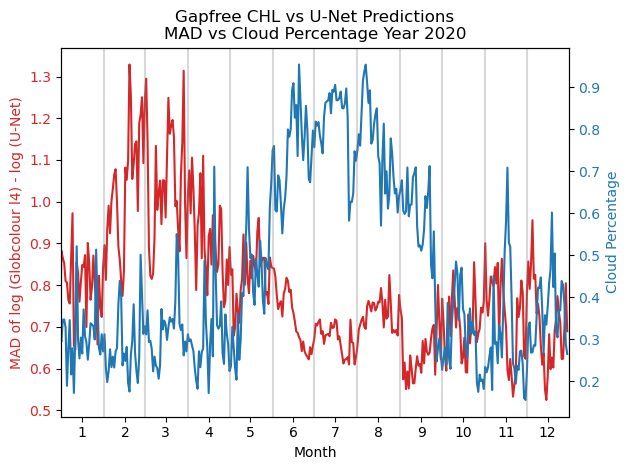

In [16]:
def get_cloud_perc(zarr_raw, year):
    zarr_time_range = zarr_raw.sel(time=str(year))
    if 'CHL_cmes-land' in zarr_raw:
        non_land_cnt = np.sum(zarr_raw['CHL_cmes-land'].values == 0)
    else:
        non_land_cnt = np.sum(~np.isnan(zarr_time_range['CHL_cmes-gapfree'].values[0]))
    clouds = zarr_time_range['CHL_cmes-cloud'].values
    cloud_perc = np.sum(clouds == 1, axis=(1, 2)) / non_land_cnt
    return cloud_perc


def yearly_MAD_vs_cloud(zarr_raw, model, year):
    # Input: all 13 standardized channels for the whole year, straight from ds_std
    X = np.stack(
        [np.nan_to_num(ds_std[v].sel(time=str(year)).values, nan=0.0) for v in X_vars],
        axis=-1
    ).astype(np.float32)

    predicted_CHL_std = model.predict(X, batch_size=8, verbose=0)[:, :, :, 0]
    predicted_CHL = (predicted_CHL_std * y_std) + y_mean

    zarr_year = zarr_raw.sel(time=str(year))
    with np.errstate(divide='ignore', invalid='ignore'):
        true_CHL = np.log(zarr_year['CHL_cmes-gapfree'].values)
        flag = zarr_year['CHL_cmes-level3'].values

    predicted_CHL = np.where(~np.isnan(flag), np.nan, predicted_CHL)

    mae = [mtg.compute_mae(true, pred) for true, pred in zip(true_CHL, predicted_CHL)]
    cloud_perc = get_cloud_perc(zarr_raw, year)

    fig, ax1 = plt.subplots()
    ax1.set_xlabel('Month')
    ax1.set_ylabel('MAD of log (Globcolour l4) - log (U-Net)', color='tab:red')
    ax1.plot(mae, color='tab:red')
    ax1.tick_params(axis='y', labelcolor='tab:red')

    ax2 = ax1.twinx()
    ax2.set_ylabel('Cloud Percentage', color='tab:blue')
    ax2.plot(cloud_perc, color='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    tick_pos, tick_label, total_day = [], [], 1
    tick_pos.append(total_day + 15)
    tick_label.append('1')
    for month in range(1, 12):
        total_day += calendar.monthrange(year, month)[1]
        plt.axvline(total_day, color='grey', alpha=0.3)
        tick_pos.append(total_day + 15)
        tick_label.append(str(month + 1))

    plt.title(f'Gapfree CHL vs U-Net Predictions\nMAD vs Cloud Percentage Year {year}')
    plt.xlim(1, len(mae))
    plt.xticks(tick_pos, tick_label)
    fig.tight_layout()
    plt.show()

# Run Annual Evaluation
yearly_MAD_vs_cloud(ds_cropped, model, 2020)
